# Norm & Flow Embedding Space: Per-Book Distributions

Loads Qwen3-Embedding-8B embeddings for all norms and flows in fiction10,
reduces to 2D via UMAP, and compares per-book distributions in the shared
embedding space.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from scipy.spatial.distance import cdist
from pathlib import Path

DATA_DIR = Path("/share/pierson/matt/n2s4cir/data/fiction10")

# Load data
norms = pd.read_parquet(DATA_DIR / "abstracted_norms.parquet")
norms = norms[norms["raz_norm_articulation"].notna() & (norms["raz_norm_articulation"] != "")].reset_index(drop=True)
flows = pd.read_parquet(DATA_DIR / "ci_flows.parquet")

norm_emb = np.load(DATA_DIR / "norm_embeddings_qwen3emb.npy")
flow_emb = np.load(DATA_DIR / "flow_embeddings_qwen3emb.npy")

assert len(norms) == norm_emb.shape[0], f"Norm count mismatch: {len(norms)} vs {norm_emb.shape[0]}"
assert len(flows) == flow_emb.shape[0], f"Flow count mismatch: {len(flows)} vs {flow_emb.shape[0]}"

print(f"Norms: {norm_emb.shape}, Flows: {flow_emb.shape}")

Norms: (11554, 4096), Flows: (1241, 4096)


In [57]:
# Build combined embedding matrix with labels
all_emb = np.vstack([norm_emb, flow_emb])

construct = np.array(["norm"] * len(norms) + ["flow"] * len(flows))
book = np.concatenate([norms["book_title"].values, flows["book_title"].values])

print(f"Combined: {all_emb.shape}")
print(f"Books: {sorted(set(book))}")

Combined: (12795, 4096)
Books: ["Alice's Adventures in Wonderland", 'Anna Karenina', 'Bleak House', 'Les Misérables', 'Middlemarch', 'Nineteen Eighty-Four', 'Pride and Prejudice', 'The Age of Innocence', 'The Count of Monte Cristo', 'The Picture of Dorian Gray']


In [58]:
# UMAP reduction to 2D
reducer = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=30,
    min_dist=0.1,
    random_state=42,
)
umap_2d = reducer.fit_transform(all_emb)
print(f"UMAP output: {umap_2d.shape}")

/share/pierson/matt/UAIR/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output: (12795, 2)


In [59]:
# Build a combined DataFrame for plotting
df_plot = pd.DataFrame({
    "x": umap_2d[:, 0],
    "y": umap_2d[:, 1],
    "construct": construct,
    "book": book,
})
df_plot.head()

,x,y,construct,book
0,13.093521,4.085541,norm,Pride and Prejudice
1,10.793343,5.004666,norm,Pride and Prejudice
2,12.301729,5.197647,norm,Pride and Prejudice
3,10.763495,5.555495,norm,Pride and Prejudice
4,11.031553,5.580851,norm,Pride and Prejudice


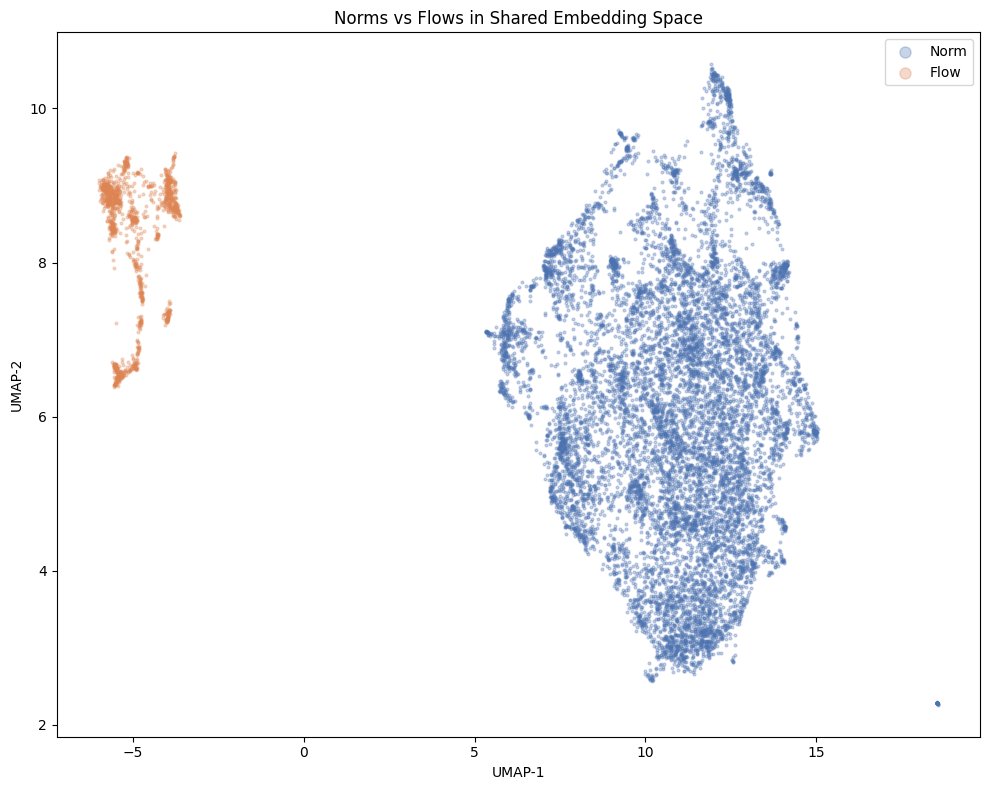

In [60]:
# --- Plot 1: All points, colored by construct type (norm vs flow) ---
fig, ax = plt.subplots(figsize=(10, 8))
colors = {"norm": "#4C72B0", "flow": "#DD8452"}
for ct in ["norm", "flow"]:
    mask = df_plot["construct"] == ct
    ax.scatter(
        df_plot.loc[mask, "x"],
        df_plot.loc[mask, "y"],
        c=colors[ct], label=ct.capitalize(),
        alpha=0.3, s=4, rasterized=True,
    )
ax.set_title("Norms vs Flows in Shared Embedding Space")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

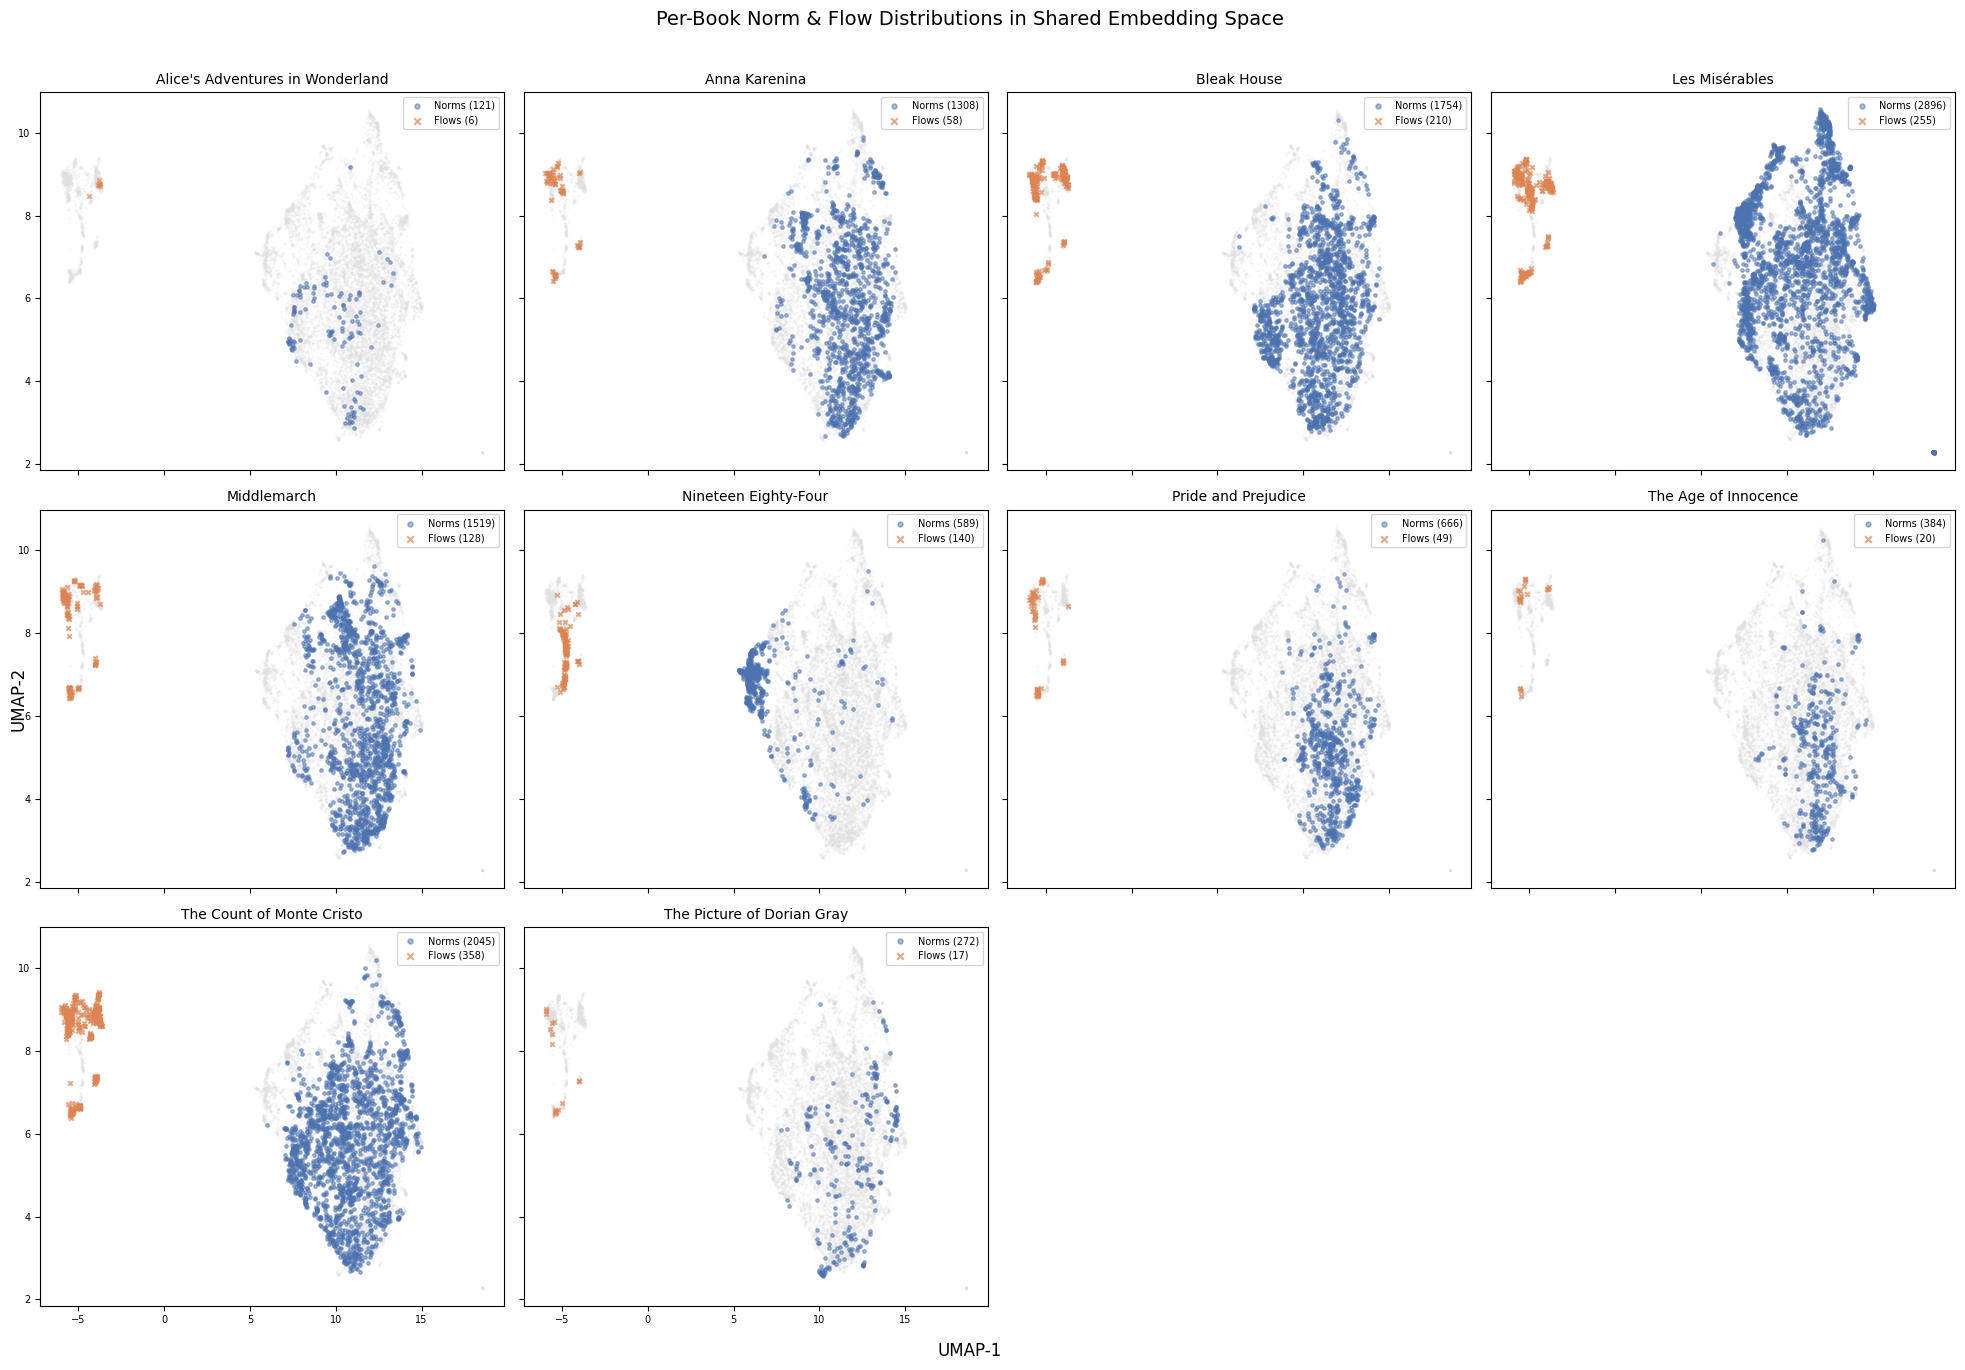

In [61]:
# --- Plot 2: Per-book faceted grid, norms vs flows ---
books_sorted = sorted(df_plot["book"].unique())
n_books = len(books_sorted)
ncols = 4
nrows = (n_books + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, bk in enumerate(books_sorted):
    ax = axes[i]
    # Background: all other points
    other = df_plot[df_plot["book"] != bk]
    ax.scatter(other["x"], other["y"], c="#E0E0E0", s=1, alpha=0.15, rasterized=True)
    # This book's norms and flows
    bk_norms = df_plot[(df_plot["book"] == bk) & (df_plot["construct"] == "norm")]
    bk_flows = df_plot[(df_plot["book"] == bk) & (df_plot["construct"] == "flow")]
    ax.scatter(bk_norms["x"], bk_norms["y"], c="#4C72B0", s=6, alpha=0.5, label=f"Norms ({len(bk_norms)})", rasterized=True)
    ax.scatter(bk_flows["x"], bk_flows["y"], c="#DD8452", s=10, alpha=0.7, label=f"Flows ({len(bk_flows)})", marker="x", rasterized=True)
    ax.set_title(bk, fontsize=10)
    ax.legend(fontsize=7, loc="upper right", markerscale=1.5)
    ax.tick_params(labelsize=7)

# Hide unused axes
for j in range(n_books, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Per-Book Norm & Flow Distributions in Shared Embedding Space", fontsize=14, y=1.01)
fig.supxlabel("UMAP-1")
fig.supylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [63]:
# --- Summary statistics: per-book centroid distances ---
from scipy.spatial.distance import cdist

# Compute per-book centroids for norms and flows separately
records = []
for bk in books_sorted:
    bk_norm_mask = (book == bk) & (construct == "norm")
    bk_flow_mask = (book == bk) & (construct == "flow")
    n_norms = bk_norm_mask.sum()
    n_flows = bk_flow_mask.sum()

    norm_centroid = all_emb[bk_norm_mask].mean(axis=0) if n_norms > 0 else None
    flow_centroid = all_emb[bk_flow_mask].mean(axis=0) if n_flows > 0 else None

    # Intra-book norm-flow centroid cosine distance
    if norm_centroid is not None and flow_centroid is not None:
        cos_dist = float(cdist([norm_centroid], [flow_centroid], metric="cosine")[0, 0])
    else:
        cos_dist = None

    # Intra-book norm spread (mean pairwise cosine dist to centroid)
    if n_norms > 1:
        norm_spread = float(cdist(all_emb[bk_norm_mask], [norm_centroid], metric="cosine").mean())
    else:
        norm_spread = None

    records.append({
        "book": bk,
        "n_norms": int(n_norms),
        "n_flows": int(n_flows),
        "norm_flow_cos_dist": cos_dist,
        "norm_spread": norm_spread,
    })

df_stats = pd.DataFrame(records)
df_stats

,book,n_norms,n_flows,norm_flow_cos_dist,norm_spread
0,Alice's Adventures in Wonderland,121,6,0.428190,0.268817
1,Anna Karenina,1308,58,0.408871,0.290449
2,Bleak House,1754,210,0.411558,0.278146
3,Les Misérables,2896,255,0.412617,0.297528
4,Middlemarch,1519,128,0.410985,0.285562
5,Nineteen Eighty-Four,589,140,0.396493,0.252511
6,Pride and Prejudice,666,49,0.380844,0.256651
7,The Age of Innocence,384,20,0.400150,0.256554
8,The Count of Monte Cristo,2045,358,0.401124,0.284950
9,The Picture of Dorian Gray,272,17,0.387370,0.280010


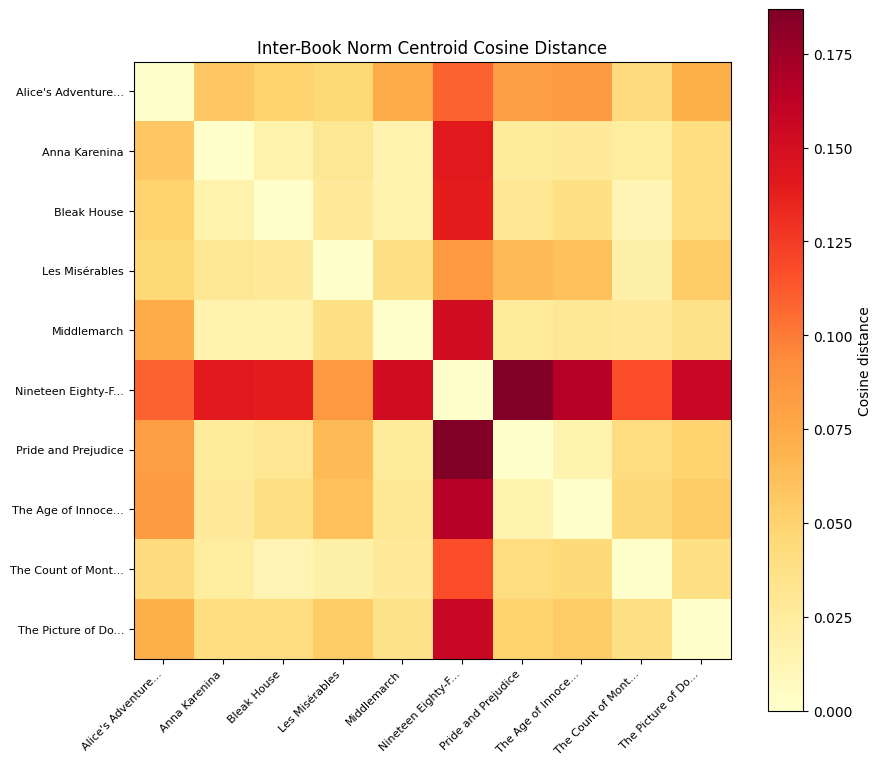

In [64]:
# --- Plot 4: Inter-book centroid distance matrix (norms only) ---
norm_centroids = np.array([
    all_emb[(book == bk) & (construct == "norm")].mean(axis=0)
    for bk in books_sorted
])
dist_mat = cdist(norm_centroids, norm_centroids, metric="cosine")

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dist_mat, cmap="YlOrRd")
ax.set_xticks(range(n_books))
ax.set_yticks(range(n_books))
short_names = [b if len(b) < 20 else b[:17] + "..." for b in books_sorted]
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_title("Inter-Book Norm Centroid Cosine Distance")
plt.colorbar(im, ax=ax, label="Cosine distance")
plt.tight_layout()
plt.show()

---
## Analysis 2: Norm vs. Flow Separation Metrics

Silhouette scores and Davies-Bouldin index for the norm/flow binary split. Per-point silhouette coefficients visualized on UMAP reveal boundary cases where norms resemble flows and vice versa.

In [66]:
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

# Binary labels: 0=norm, 1=flow
labels_binary = (construct == "flow").astype(int)

# Compute on UMAP 2D (fast) — reflects visual separation
sil_score = silhouette_score(umap_2d, labels_binary, metric="euclidean")
db_score = davies_bouldin_score(umap_2d, labels_binary)
print(f"Norm vs Flow separation (UMAP 2D):")
print(f"  Silhouette score: {sil_score:.4f}")
print(f"  Davies-Bouldin index: {db_score:.4f} (lower = better separation)")

# Per-point silhouette
sil_samples = silhouette_samples(umap_2d, labels_binary, metric="euclidean")
df_plot["silhouette"] = sil_samples

# Also compute in full embedding space (subsample for speed)
rng = np.random.default_rng(42)
n_sub = min(5000, len(all_emb))
sub_idx = rng.choice(len(all_emb), n_sub, replace=False)
sil_full = silhouette_score(all_emb[sub_idx], labels_binary[sub_idx], metric="cosine")
db_full = davies_bouldin_score(all_emb[sub_idx], labels_binary[sub_idx])
print(f"\nNorm vs Flow separation (full 4096D, {n_sub} subsample):")
print(f"  Silhouette score: {sil_full:.4f}")
print(f"  Davies-Bouldin index: {db_full:.4f}")

Norm vs Flow separation (UMAP 2D):
  Silhouette score: 0.7945
  Davies-Bouldin index: 0.2192 (lower = better separation)

Norm vs Flow separation (full 4096D, 5000 subsample):
  Silhouette score: 0.2592
  Davies-Bouldin index: 1.8755


### Publication figure: Norm/Flow Silhouette + LaTeX caption

Saved: /share/pierson/matt/UAIR/notebooks/COLM26/tables/norm_flow_silhouette.pdf


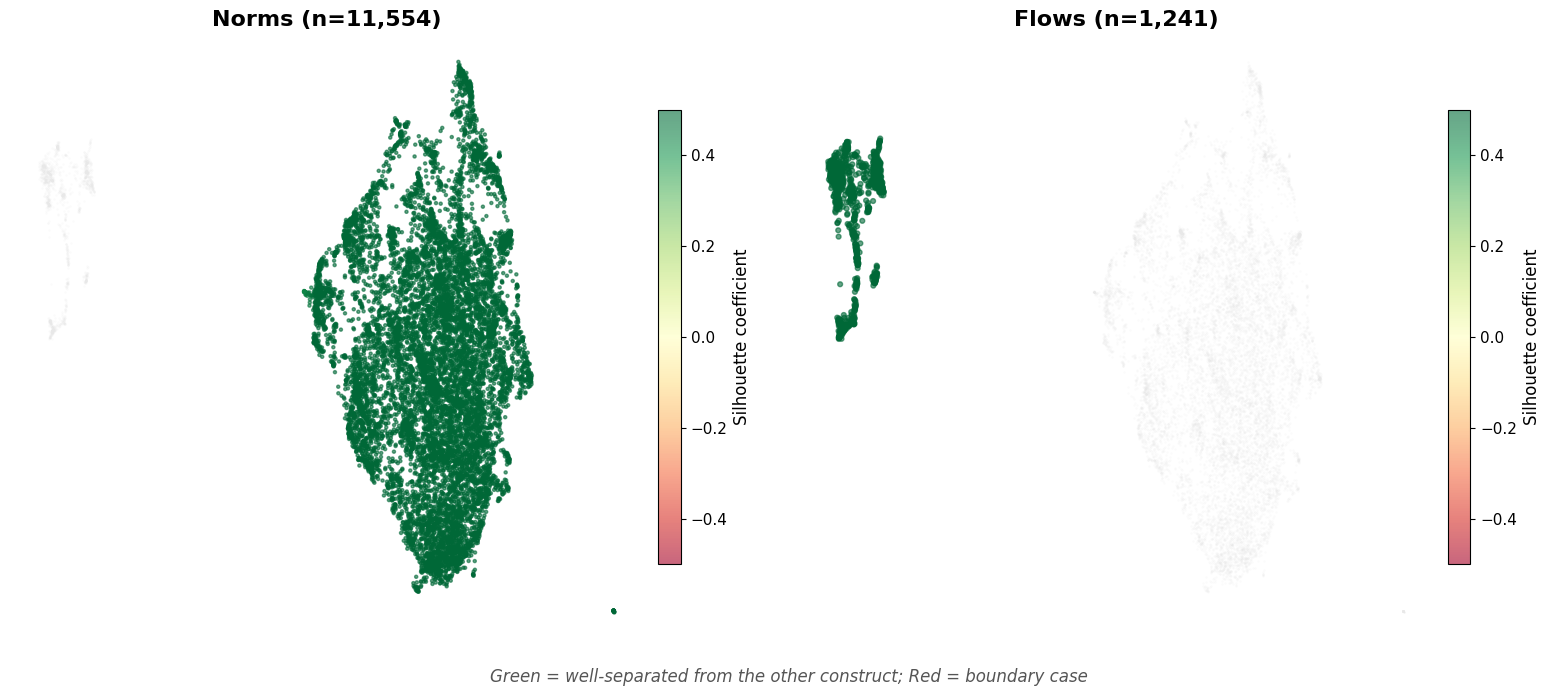

In [68]:
import matplotlib as mpl

OUT_DIR = Path("/share/pierson/matt/UAIR/notebooks/COLM26/tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Collect boundary examples for caption ---
norm_sil = df_plot[df_plot["construct"] == "norm"].copy()
norm_sil["text"] = norms.loc[norm_sil.index, "raz_norm_articulation"].values

flow_sil = df_plot[df_plot["construct"] == "flow"].copy()
flow_offset = len(norms)
flow_rows = flows.iloc[flow_sil.index - flow_offset]
flow_sil["text"] = [
    f"In {r.get('ci_context','?')} context, {r.get('ci_sender','?')} sends "
    f"{r.get('ci_information_type','?')} to {r.get('ci_recipient','?')} via "
    f"{r.get('ci_transmission_principle','?')} [{r.get('ci_appropriateness','?')}]"
    for r in flow_rows.to_dict("records")
]

top_norm_boundary = norm_sil.nsmallest(3, "silhouette")
top_flow_boundary = flow_sil.nsmallest(3, "silhouette")

# --- Polished figure ---
with mpl.rc_context({"font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
                      "xtick.labelsize": 12, "ytick.labelsize": 12}):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for idx, ct in enumerate(["norm", "flow"]):
        ax = axes[idx]
        mask = df_plot["construct"] == ct
        other = df_plot[~mask]
        ax.scatter(other["x"], other["y"], c="#E8E8E8", s=1, alpha=0.08, rasterized=True)

        sc = ax.scatter(
            df_plot.loc[mask, "x"], df_plot.loc[mask, "y"],
            c=df_plot.loc[mask, "silhouette"], cmap="RdYlGn",
            vmin=-0.5, vmax=0.5,
            s=5 if ct == "norm" else 12, alpha=0.6, rasterized=True,
        )
        title = f"{'Norms' if ct == 'norm' else 'Flows'} (n={mask.sum():,})"
        ax.set_title(title, fontsize=16, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
        cb.set_label("Silhouette coefficient", fontsize=12)
        cb.ax.tick_params(labelsize=11)

    fig.text(0.5, 0.01,
             "Green = well-separated from the other construct; Red = boundary case",
             ha="center", fontsize=12, style="italic", color="#555")

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    fig_path = OUT_DIR / "norm_flow_silhouette.pdf"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()

In [69]:
# --- Generate LaTeX caption ---
def escape_latex(s):
    return s.replace("&", r"\&").replace("%", r"\%").replace("_", r"\_").replace("#", r"\#")

norm_items = []
for _, row in top_norm_boundary.iterrows():
    norm_items.append(f"``{escape_latex(row['text'][:120])}''")

flow_items = []
for _, row in top_flow_boundary.iterrows():
    flow_items.append(f"``{escape_latex(row['text'][:150])}''")

caption = r"""\caption{Per-point silhouette coefficients for norms (left, $n=%s$) and information flows (right, $n=%s$) in a shared UMAP projection of Qwen3-Embedding-8B embeddings. Color encodes separation quality: green points are well-separated from the other construct type, while red points lie near the norm--flow boundary. The high overall silhouette score indicates that norms and flows occupy largely distinct regions of the embedding space. Boundary norms---those most similar to flows---tend to be Newspeak linguistic rules from \textit{Nineteen Eighty-Four} that prescribe information-encoding conventions rather than social behavior, e.g., %s. Boundary flows---those most similar to norms---involve family-context confidentiality violations from \textit{Bleak House} and \textit{Les Mis\'{e}rables} whose transmission principles read as prescriptive constraints, e.g., %s.}""" % (
    f"{len(norms):,}", f"{len(flows):,}",
    "; ".join(norm_items),
    "; ".join(flow_items),
)

print(caption)

# Also save to file
caption_path = OUT_DIR / "norm_flow_silhouette_caption.tex"
with open(caption_path, "w") as f:
    f.write(caption + "\n")
print(f"\nSaved: {caption_path}")

\caption{Per-point silhouette coefficients for norms (left, $n=11,554$) and information flows (right, $n=1,241$) in a shared UMAP projection of Qwen3-Embedding-8B embeddings. Color encodes separation quality: green points are well-separated from the other construct type, while red points lie near the norm--flow boundary. The high overall silhouette score indicates that norms and flows occupy largely distinct regions of the embedding space. Boundary norms---those most similar to flows---tend to be Newspeak linguistic rules from \textit{Nineteen Eighty-Four} that prescribe information-encoding conventions rather than social behavior, e.g., ``A speaker of Newspeak may insert extra letters into a word or retain archaic formations for the sake of euphony.''; ``A user of the language may strengthen words even more by adding the affix DOUBLEPLUS- for any word in the language.''; ``A user of the language may strengthen words by adding the affix PLUS- for any word in the language.''. Boundary f

---
## Analysis 5: Theme vs. Source Clustering

Do norms cluster primarily by **book** (source text) or by **theme** (`raz_context`)? We compute cluster purity for both labelings and compare. Low book-purity + high theme-purity would mean the embedding captures universal normative themes that transcend individual novels.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from collections import Counter

# Get theme labels from raz_context (norms only)
norm_contexts = norms["raz_context"].fillna("unknown").values
# Keep top-K themes, bucket the rest as "other"
theme_counts = Counter(norm_contexts)
top_themes = [t for t, c in theme_counts.most_common(15)]
norm_themes = np.array([t if t in top_themes else "other" for t in norm_contexts])

print(f"Top themes: {top_themes}")
print(f"Theme distribution:")
for t in top_themes:
    print(f"  {t:40s}  n={(norm_themes == t).sum()}")
print(f"  {'other':40s}  n={(norm_themes == 'other').sum()}")

# K-Means clustering on norm embeddings
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(norm_emb)

# Compare clustering with book labels vs theme labels
book_labels_norm = norms["book_title"].values
ari_book = adjusted_rand_score(book_labels_norm, km_labels)
nmi_book = normalized_mutual_info_score(book_labels_norm, km_labels)
ari_theme = adjusted_rand_score(norm_themes, km_labels)
nmi_theme = normalized_mutual_info_score(norm_themes, km_labels)

print(f"\nK-Means (k={n_clusters}) alignment:")
print(f"  vs Book:  ARI={ari_book:.4f}  NMI={nmi_book:.4f}")
print(f"  vs Theme: ARI={ari_theme:.4f}  NMI={nmi_theme:.4f}")
print(f"  --> {'Book' if nmi_book > nmi_theme else 'Theme'} labels explain more cluster structure")

In [ ]:
# Visualize: UMAP colored by theme (norms only)
norm_plot = df_plot[df_plot["construct"] == "norm"].copy()
norm_plot["theme"] = norm_themes

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Left: colored by book
ax = axes[0]
for i, bk in enumerate(books_sorted):
    mask = norm_plot["book"] == bk
    ax.scatter(norm_plot.loc[mask, "x"], norm_plot.loc[mask, "y"],
               c=[book_cmap(i)], s=4, alpha=0.4, label=bk, rasterized=True)
ax.legend(fontsize=7, markerscale=3, loc="best", ncol=2)
ax.set_title("Norms Colored by Source Text")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

# Right: colored by theme
ax = axes[1]
theme_cmap = plt.cm.get_cmap("tab20", len(top_themes) + 1)
theme_list = top_themes + ["other"]
for i, t in enumerate(theme_list):
    mask = norm_plot["theme"] == t
    if mask.sum() == 0:
        continue
    ax.scatter(norm_plot.loc[mask, "x"], norm_plot.loc[mask, "y"],
               c=[theme_cmap(i)], s=4, alpha=0.4, label=t, rasterized=True)
ax.legend(fontsize=6, markerscale=3, loc="best", ncol=2)
ax.set_title("Norms Colored by Theme (raz_context)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

plt.suptitle("Source Text vs. Thematic Context: Which Organizes the Embedding Space?", fontsize=14)
plt.tight_layout()
plt.show()

---
## Analysis 7: UMAP Stability Analysis

Run UMAP with 5 different random seeds and measure how consistently points cluster together (Jaccard similarity of k-NN neighborhoods). Points with high stability are robustly positioned; low-stability points are sensitive to projection.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Run UMAP with different seeds
seeds = [42, 123, 456, 789, 1024]
k = 15  # neighborhood size for stability

all_projections = []
all_nn_sets = []
for seed in seeds:
    r = umap.UMAP(n_components=2, metric="cosine", n_neighbors=30, min_dist=0.1, random_state=seed)
    proj = r.fit_transform(all_emb)
    all_projections.append(proj)
    # k-NN in projected space
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(proj)
    _, indices = nn.kneighbors(proj)
    all_nn_sets.append([set(idx) for idx in indices])
    print(f"  Seed {seed} done")

# Compute per-point mean Jaccard stability across all seed pairs
n_pts = len(all_emb)
stability = np.zeros(n_pts)
n_pairs = 0
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        for p in range(n_pts):
            jaccard = len(all_nn_sets[i][p] & all_nn_sets[j][p]) / len(all_nn_sets[i][p] | all_nn_sets[j][p])
            stability[p] += jaccard
        n_pairs += 1
stability /= n_pairs

print(f"\nMean stability: {stability.mean():.4f}")
print(f"Median stability: {np.median(stability):.4f}")
print(f"Norms mean: {stability[:len(norms)].mean():.4f}, Flows mean: {stability[len(norms):].mean():.4f}")

In [ ]:
# Visualize stability on the primary UMAP projection
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: stability heatmap
ax = axes[0]
sc = ax.scatter(umap_2d[:, 0], umap_2d[:, 1], c=stability, cmap="viridis",
                s=3, alpha=0.5, rasterized=True, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label="Mean Jaccard stability (k=15)", shrink=0.8)
ax.set_title("UMAP Projection Stability")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

# Right: stability distribution by construct
ax = axes[1]
ax.hist(stability[:len(norms)], bins=50, alpha=0.6, label="Norms", color="#4C72B0", density=True)
ax.hist(stability[len(norms):], bins=50, alpha=0.6, label="Flows", color="#DD8452", density=True)
ax.axvline(stability.mean(), color="black", linestyle="--", label=f"Mean={stability.mean():.3f}")
ax.set_xlabel("Jaccard Stability")
ax.set_ylabel("Density")
ax.set_title("Stability Distribution: Norms vs Flows")
ax.legend()

plt.tight_layout()
plt.show()

---
## Analysis 8: Intrinsic Dimensionality

Estimate the local intrinsic dimensionality (LID) of norm vs. flow embeddings using the MLE estimator. Lower intrinsic dimensionality means the data lies on a tighter manifold. Visualized as per-point heatmap on UMAP.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def estimate_lid_mle(distances_to_neighbors: np.ndarray) -> np.ndarray:
    """MLE estimator of local intrinsic dimensionality (Levina & Bickel 2004).

    distances_to_neighbors: (n_points, k) array of distances to k nearest neighbors.
    Returns: (n_points,) array of LID estimates.
    """
    # Exclude the point itself (distance 0) — use columns 1: if self is included
    dists = distances_to_neighbors[:, 1:]  # (n, k-1)
    # Avoid log(0)
    dists = np.maximum(dists, 1e-10)
    k = dists.shape[1]
    # r_max = distance to k-th neighbor
    r_max = dists[:, -1:]  # (n, 1)
    # LID = -k / sum(log(r_j / r_max))
    log_ratios = np.log(dists[:, :-1] / r_max)
    lid = -(k - 1) / log_ratios.sum(axis=1)
    return lid

# Compute k-NN distances in full embedding space
k_lid = 20
nn = NearestNeighbors(n_neighbors=k_lid + 1, metric="cosine").fit(all_emb)
dists, _ = nn.kneighbors(all_emb)

lid_values = estimate_lid_mle(dists)
# Clip outliers for visualization
lid_clipped = np.clip(lid_values, 0, np.percentile(lid_values, 99))

print(f"LID statistics (MLE, k={k_lid}):")
print(f"  Overall: mean={lid_values.mean():.1f}, median={np.median(lid_values):.1f}")
print(f"  Norms:   mean={lid_values[:len(norms)].mean():.1f}, median={np.median(lid_values[:len(norms)]):.1f}")
print(f"  Flows:   mean={lid_values[len(norms):].mean():.1f}, median={np.median(lid_values[len(norms):]):.1f}")

In [ ]:
# Visualize LID on UMAP
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: LID heatmap on UMAP
ax = axes[0]
sc = ax.scatter(umap_2d[:, 0], umap_2d[:, 1], c=lid_clipped, cmap="plasma",
                s=3, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label=f"Local Intrinsic Dimensionality (k={k_lid})", shrink=0.8)
ax.set_title("Local Intrinsic Dimensionality on UMAP")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

# Right: LID distribution by construct
ax = axes[1]
ax.hist(lid_values[:len(norms)], bins=60, alpha=0.6, label="Norms", color="#4C72B0", density=True, range=(0, np.percentile(lid_values, 99)))
ax.hist(lid_values[len(norms):], bins=60, alpha=0.6, label="Flows", color="#DD8452", density=True, range=(0, np.percentile(lid_values, 99)))
ax.axvline(lid_values[:len(norms)].mean(), color="#4C72B0", linestyle="--", label=f"Norm mean={lid_values[:len(norms)].mean():.1f}")
ax.axvline(lid_values[len(norms):].mean(), color="#DD8452", linestyle="--", label=f"Flow mean={lid_values[len(norms):].mean():.1f}")
ax.set_xlabel("Local Intrinsic Dimensionality")
ax.set_ylabel("Density")
ax.set_title("LID Distribution: Norms vs Flows")
ax.legend()

plt.tight_layout()
plt.show()

# Per-book LID
print("\nPer-book mean LID (norms):")
for bk in books_sorted:
    bk_mask = (book == bk) & (construct == "norm")
    if bk_mask.sum() > 0:
        print(f"  {bk:40s}  LID={lid_values[bk_mask].mean():.1f}  n={bk_mask.sum()}")